# Notebook 1: fMRI & Voxels

Before we dive in, it's worth acknowledging that these tutorials are designed for people with limited experience in decoding. With that in mind, you might find yourself asking questions like:



*   **How is this even possible?**
*   **What exactly are we predicting?**
*   **What does “reconstruction” actually mean here?**  

By the end of this tutorial, the answers to these questions (and many others) should become intuitively clear. However, rather than addressing all of them upfront, I want to tackle the first one directly and make a few subsequent points.


# How is this possible?

At its core, fMRI-based visual reconstruction rests on a deceptively simple idea: when you look at an image, your brain produces patterns of activity that systematically relate to the visual features in that image and these patterns are consistent enough to be learned and reversed.

## The Encoding-Decoding Framework

Think of the brain as an **encoder**. It takes a high-dimensional image and transforms it into a pattern of neural activity.

$$\text{Image} \xrightarrow{\text{Brain (Encoder)}} \text{Neural Activity}$$

Our job is to build a **decoder**, a model that reverses this process:

$$\text{Neural Activity} \xrightarrow{\text{Our Model (Decoder)}} \text{Reconstructed Image}$$

This is what we mean by "visual reconstruction" or "decoding." We're not reading minds in any mystical sense—we're learning a mathematical mapping from brain patterns back to images. The brain, of course, does the encoding for free, we just need to learn to undo it.

# What fMRI Actually Measures

Functional Magnetic Resonance Imaging (fMRI) doesn't directly measure neural activity. Instead, it measures changes in blood oxygenation levels across the brain—what's known as the BOLD signal (Blood Oxygen Level Dependent). When neurons in a particular region become active, they consume oxygen, triggering increased blood flow to that area. fMRI detects these changes.

fMRI divides the brain into a 3D grid of tiny cubes called **voxels** (volumetric pixels). Each voxel is typically 2-3mm on each side and contains hundreds of thousands of neurons. For every voxel, fMRI gives us a single number representing the BOLD signal at that location.

This means a brain scan is essentially a long vector of numbers:

$$b = [b_1, b_2, b_3, ..., b_n]$$

Where:
- $b_i$ = the BOLD signal in voxel $i$
- $n$ = total number of voxels

When we talk about "brain activity" throughout this tutorial, we're really talking about this vector $b$ a high-dimensional snapshot of blood oxygenation levels across the brain at a given moment.

## Working with NSD Data

Now that we understand what fMRI measures, let's get our hands on some real data. We'll be using the **Natural Scenes Dataset (NSD)**—one of the largest and most comprehensive fMRI datasets available for visual neuroscience.

### What is NSD?

The Natural Scenes Dataset is a massive publicly available dataset where 8 subjects viewed thousands of natural images while undergoing high-resolution fMRI scanning.

### Why NSD?

NSD has become the benchmark dataset for visual reconstruction research for several reasons:

1. **Scale** — Thousands of image-brain pairs per subject (deep learning loves data)
2. **Quality** — 7 Tesla scanning provides exceptional signal quality
3. **Standardization** — Preprocessed and organized, ready for machine learning
4. **Natural images** — Complex, real-world scenes rather than simple stimuli

With that being said lets load it up!

In [ ]:
# Install dependencies
!pip install -q nibabel numpy matplotlib webdataset braceexpand nilearn

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 36.3 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import io
import numpy as np
import matplotlib.pyplot as plt
import webdataset as wds
import braceexpand
import nilearn
from PIL import Image


In [ ]:
def load_nsd_subset(subject_id=1, shards="0..5", max_samples=500):
    """Load a subset of NSD training data."""

    base_url = "https://huggingface.co/datasets/pscotti/naturalscenesdataset/resolve/main/webdataset_avg_new"
    url_pattern = f"{base_url}/train/train_subj0{subject_id}_{{{shards}}}.tar"
    urls = list(braceexpand.braceexpand(url_pattern))

    print(f" Loading NSD Subject {subject_id}")
    print(f" Shards: {shards} ({len(urls)} files)")

    dataset = wds.WebDataset(urls)

    voxels_list = []
    images_list = []

    for sample in dataset:
        # Get voxels with the nsdgeneral.npy mask
        voxels = np.load(io.BytesIO(sample['nsdgeneral.npy']))

        # Get image
        img = Image.open(io.BytesIO(sample['jpg'])).convert('RGB')
        image = np.array(img) / 255.0

        voxels_list.append(voxels)
        images_list.append(image)

        if len(voxels_list) % 100 == 0:
            print(f"   Loaded {len(voxels_list)} samples...")

        if len(voxels_list) >= max_samples:
            break

    voxels = np.stack(voxels_list)
    images = np.stack(images_list)

    print(f"   Loaded {len(voxels)} samples")
    print(f"   Voxels: {voxels.shape}")
    print(f"   Images: {images.shape}")

    return voxels, images


In [ ]:
# Load data
voxels, images = load_nsd_subset(subject_id=1, shards="0..5", max_samples=500) #500 Images only for now.

 Loading NSD Subject 1
 Shards: 0..5 (6 files)
   Loaded 100 samples...
   Loaded 200 samples...
   Loaded 300 samples...
   Loaded 400 samples...
   Loaded 500 samples...
   Loaded 500 samples
   Voxels: (500, 3, 15724)
   Images: (500, 224, 224, 3)


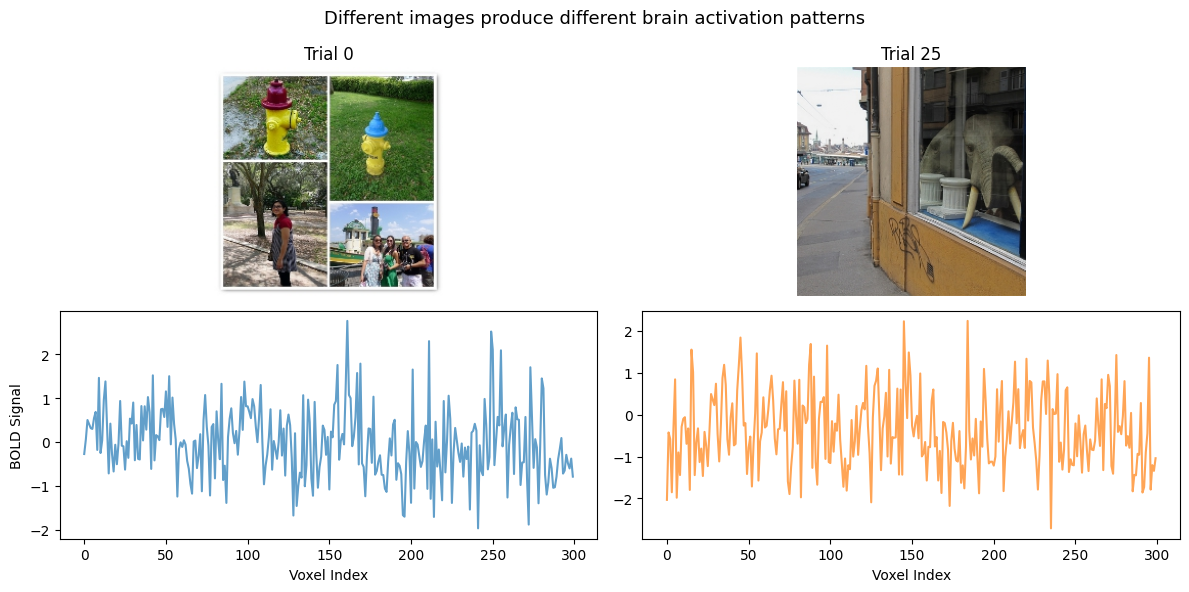

In [ ]:
trial_a, trial_b = 0, 25
voxel_range = slice(0, 300)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].imshow(images[trial_a])
axes[0, 0].set_title(f'Trial {trial_a}')
axes[0, 0].axis('off')

axes[0, 1].imshow(images[trial_b])
axes[0, 1].set_title(f'Trial {trial_b}')
axes[0, 1].axis('off')

axes[1, 0].plot(voxels[trial_a, 0, voxel_range], color='C0', alpha=0.7)
axes[1, 0].set_ylabel('BOLD Signal')
axes[1, 0].set_xlabel('Voxel Index')

axes[1, 1].plot(voxels[trial_b, 0, voxel_range], color='C1', alpha=0.7)
axes[1, 1].set_xlabel('Voxel Index')

plt.suptitle('Different images produce different brain activation patterns', fontsize=13)
plt.tight_layout()
plt.show()

## Exploring the Data

Before diving into the theory, let's get our hands dirty and explore what we just loaded. Understanding the shape and characteristics of your data is always the first step.

### Why 3 Repetitions?

You may notice our voxel data has shape `(samples, 3, 15724)`. Each image in NSD was shown to the subject **three times** across different scanning sessions. The main reason for this is that single-trial fMRI data suffers from an extremely low signal-to-noise ratio, capturing significant fluctuations from physiological processes and background neural activity not immediately relevant to the visual task. To accurately determine how a stimulus is represented in the brain, multiple repetitions are effectively essential.

### How should you use them?

You have two main options. The first is to average across the three repetitions for each image. Since the true brain response to an image stays roughly the same each time while the noise fluctuates randomly, averaging cancels out much of the noise and gives you a cleaner signal. The tradeoff is that this reduces your total number of samples. The second option is to treat each repetition as its own training sample, which gives you 3x more training data but with noisier individual samples.

Averaging works well when you want the most faithful representation of how the brain responds to each image. Keeping them separate tends to benefit deep learning models that are data-hungry and can learn to handle noise on their own. The best choice depends on your model architecture and training strategy, and the webdataset provides all three repetitions so you're free to go either way.

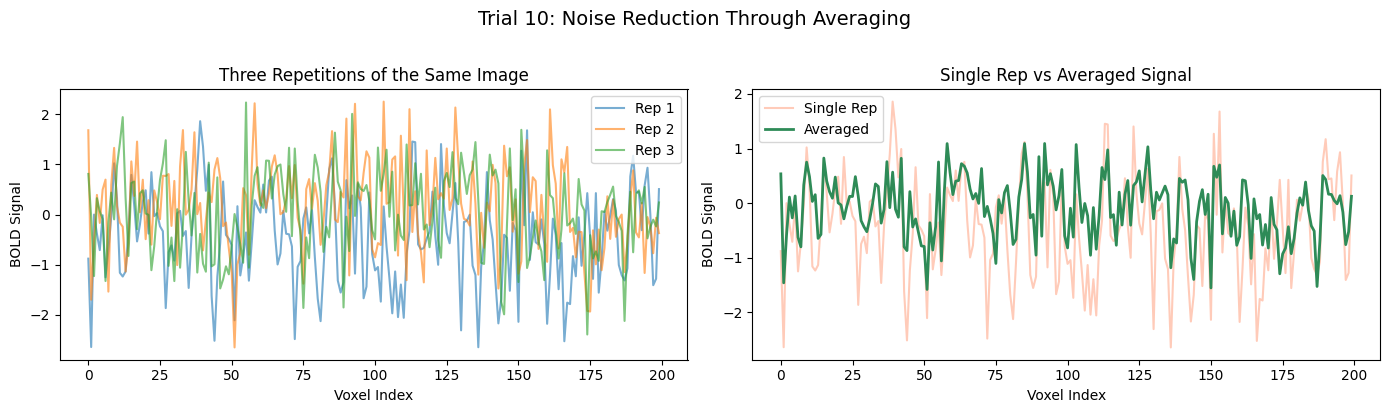

Std of single repetition: 1.0674
Std of averaged signal:   0.6123
Averaging reduced variance by 42.6%


In [ ]:
# Visualize the effect of averaging repetitions
trial = 10

# Plot 1: Overlay all three repetitions to show variability
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Show a slice of voxels across repetitions so you can see the fluctuation
voxel_range = slice(0, 200)

for rep in range(3):
    axes[0].plot(voxels[trial, rep, voxel_range], alpha=0.6, label=f'Rep {rep+1}')
axes[0].set_title('Three Repetitions of the Same Image')
axes[0].set_xlabel('Voxel Index')
axes[0].set_ylabel('BOLD Signal')
axes[0].legend()

# Show averaged signal on top of a single rep for direct comparison
axes[1].plot(voxels[trial, 0, voxel_range], alpha=0.4, color='coral', label='Single Rep')
axes[1].plot(voxels[trial].mean(axis=0)[voxel_range], color='seagreen', linewidth=2, label='Averaged')
axes[1].set_title('Single Rep vs Averaged Signal')
axes[1].set_xlabel('Voxel Index')
axes[1].set_ylabel('BOLD Signal')
axes[1].legend()

plt.suptitle(f'Trial {trial}: Noise Reduction Through Averaging', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Quantify the difference
single_std = voxels[trial, 0, :].std()
averaged_std = voxels[trial].mean(axis=0).std()
print(f"Std of single repetition: {single_std:.4f}")
print(f"Std of averaged signal:   {averaged_std:.4f}")
print(f"Averaging reduced variance by {(1 - averaged_std/single_std) * 100:.1f}%")

### The nsdgeneral Mask: Where Vision Lives

When we load voxel data from NSD, we're not loading the *entire* brain. Instead, we focus on the **nsdgeneral** masked voxels.

### What is nsdgeneral?

The `nsdgeneral` mask is a binary ROI (Region of Interest) that spans the visually-responsive cortex. It includes early visual areas (V1, V2, V3) where basic features like edges are processed, higher visual areas (V4, LO, IT) where complex shapes emerge, and specialized regions for faces and places (FFA, PPA).

This mask contains approximately **15,724 voxels** per subject, carefully selected because they show reliable responses to visual stimuli.

### How Binary Masking Works

We call this a "binary" mask because it operates on a strict **Keep (1) or Discard (0)** logic.

Think of the mask as a rigid filter applied to the 3D brain volume:
* **1 (Keep):** If a voxel is inside the visual cortex, we retain its data.
* **0 (Discard):** If a voxel is outside these regions, we ignore it entirely.

Unlike other masking techniques that might "softly" weight regions by importance, a binary mask completely removes data from non-visual areas. We  are effectively cutting voxels out of our dataset to ensure we only analyze the signal relevant to vision.

### Why Use a Mask At All?

$$\text{Full brain} \approx 200,000 \text{ voxels}$$
$$\text{nsdgeneral} \approx 15,724 \text{ voxels}$$

By focusing on visually-responsive regions, we reduce noise from irrelevant brain areas, improve computational efficiency, and boost the signal that actually encodes visual information. The voxel vector we loaded earlier comes pre-masked to `nsdgeneral`, so each sample is already optimized for visual decoding.

In [ ]:
import urllib.request
import nibabel as nib

os.makedirs('nsd_data', exist_ok=True)

subject = 1
subj_str = f'subj0{subject}'
base_url = "https://natural-scenes-dataset.s3.amazonaws.com/nsddata"

# ROI files
roi_files = {
    'nsdgeneral': f'{base_url}/ppdata/{subj_str}/func1pt8mm/roi/nsdgeneral.nii.gz',
    'visual_rois': f'{base_url}/ppdata/{subj_str}/func1pt8mm/roi/prf-visualrois.nii.gz',
    'face_rois': f'{base_url}/ppdata/{subj_str}/func1pt8mm/roi/floc-faces.nii.gz',
    'place_rois': f'{base_url}/ppdata/{subj_str}/func1pt8mm/roi/floc-places.nii.gz',
}

# Anatomical reference
anat_files = {
    'T1': f'{base_url}/ppdata/{subj_str}/func1pt8mm/T1_to_func1pt8mm.nii.gz',
}

print(f" Downloading NSD data for Subject {subject}...")

for name, url in {**roi_files, **anat_files}.items():
    filepath = f'nsd_data/{name}.nii.gz'
    if not os.path.exists(filepath):
        try:
            print(f"   Downloading {name}...")
            urllib.request.urlretrieve(url, filepath)
        except Exception as e:
            print(f"    Failed: {e}")
    else:
        print(f"   {name} exists")


## Visualizing Brain Activity

Now that we have our voxel data (a 1D vector) and the nsdgeneral mask (a 3D binary volume), we need to **map them back together** for visualization.

### The Mapping Process

The webdataset provides voxels as a flattened array:
$$\text{voxels} = [v_1, v_2, v_3, ..., v_{15724}]$$

The nsdgeneral mask tells us *where* in 3D space each voxel belongs. We load the mask, find the 3D coordinates where `mask > 0`, and insert each voxel value at its corresponding location. This gives us a 3D brain volume we can visualize alongside the T1 anatomical image.

In [ ]:
# Clean NSD Brain Visualization with nilearn
from nilearn import plotting
import nibabel as nib

# Load data
t1_img = nib.load('nsd_data/T1.nii.gz')
roi_img = nib.load('nsd_data/nsdgeneral.nii.gz')
roi_data = roi_img.get_fdata()

# Pick a trial
trial_idx = np.random.randint(len(images))
trial_voxels = voxels[trial_idx]
if trial_voxels.ndim > 1:
    trial_voxels = trial_voxels.mean(axis=0)

# Map to 3D volume
roi_indices = np.where(roi_data > 0)
activation_volume = np.zeros_like(roi_data, dtype=np.float32)
activation_volume[roi_indices] = trial_voxels.astype(np.float32)
activation_nii = nib.Nifti1Image(activation_volume, roi_img.affine, roi_img.header)

vmax = float(np.percentile(np.abs(trial_voxels), 98))

# Show stimulus
print(f" Stimulus Image #{trial_idx}")
plt.figure(figsize=(5, 5))
plt.imshow(images[trial_idx])
plt.axis('off')
plt.title(f'Image #{trial_idx}', fontsize=12)
plt.show()

# Show brain activation
plotting.view_img(
    activation_nii,
    bg_img=t1_img,
    threshold=0.2,
    cmap='cold_hot',
    symmetric_cmap=True,
    vmax=vmax,
    title=f'Brain Activity #{trial_idx}'
)

## The Reconstruction Challenge

Visual reconstruction is fundamentally an **inverse problem**. The brain transforms a high-dimensional image into a pattern of neural activity. Reconstruction asks us to reverse this process.

Consider the dimensionality mismatch: we have ~15,000 voxels trying to predict an image with ~200,000 pixels (256×256 RGB). This is severely underdetermined. There are infinitely many images that could produce similar brain activity.

What makes this tractable? The space of *natural*  images is highly structured. Modern generative models have learned these structures, and by mapping brain activity into their latent spaces, we can leverage this prior knowledge to resolve the ambiguity.

In the next notebook, we'll explore **Variational Autoencoders (VAEs)** which are models that compress images into compact latent representations, giving us a more tractable target to predict from brain activity. We'll continue with our [Notebook 2: Variational Autoencoders](https://colab.research.google.com/drive/1lrT398xL_wdc6Pr1-Vrgja10OWm9C1xQ)